In [1]:
import ROOT as rt
import sys
import collections
from collections import OrderedDict
import uproot
import pandas as pd

import scipy
import awkward as ak
import time

import subprocess
GIT_REPO = subprocess.Popen(['git', 'rev-parse', '--show-toplevel'], stdout=subprocess.PIPE).communicate()[0].rstrip().decode('utf-8')
sys.path.append(GIT_REPO + '/lib/')
from histo_utilities import create_TH1D, create_TH2D, std_color_list, create_TGraph, make_ratio_plot
from helper_functions import *
import matplotlib.pyplot as plt

import numpy as np
from scipy.stats import norm
import math
import CMS_lumi, tdrstyle
style = tdrstyle.setTDRStyle()
CMS_lumi.writeExtraText = 0


print(sys.version)

Welcome to JupyROOT 6.24/06
3.6.8 (default, Nov  2 2021, 13:01:57) 
[GCC 8.4.1 20200928 (Red Hat 8.4.1-1)]


# Load ntuples

In [2]:
%%time

fpath =OrderedDict()
tree = OrderedDict()

start_t = time.time()
version = 'v30'
# for data_year in ['2024']:
for data_year in ['all']:

    # path = "/storage/af/user/christiw/login-1/christiw/LLP/Run3/CMSSW_14_0_1/src/mds_analysis/data/raw/"
    # fpath_bkg[data_year] = path + f"data_{data_year}_goodLumi.root"
    if data_year == 'all':path = f'/storage/af/group/phys_exotica/delayedjets/displacedJetMuonAnalyzer/Run3/V1p19//Data_all/{version}/normalized/'
    else: path = f'/storage/af/group/phys_exotica/delayedjets/displacedJetMuonAnalyzer/Run3/V1p19//Data{data_year}/{version}/normalized/'
    if data_year == '2022':fpath['data'+data_year] = path + "DisplacedJet-EXOCSCCluster_Run2022-PromptReco_goodLumi.root"
    elif data_year == '2023':fpath['data'+data_year] = path + "Muon-EXOCSCCluster_Run2023-PromptReco_goodLumi.root"
    elif data_year == '2024':fpath['data'+data_year] = path + "Muon-EXOCSCCluster_Run2024-PromptReco_goodLumi.root"
    elif data_year == 'all':fpath['data'+data_year] = path + "EXOCSCCluster_Run2022_2024_goodLumi.root"

fpath['sig'] = f'/storage/af/group/phys_exotica/delayedjets/displacedJetMuonAnalyzer/Run3/V1p19/MC_all/{version}/normalized/ggH_Hto2Sto4B_MH-125-MS-15-ctauS-1000_TuneCP5_13p6TeV_powheg-pythia8_160000pb_weighted.root'
NEvents = {}
for k,v in fpath.items():
    print (k, v)
    root_dir = uproot.open(v) 

    tree[k] = root_dir['MuonSystem']
    NEvents[k] = root_dir['NEvents'].values()[0]
    # NEvents[k] = root_dir['NEvents'].counts()
    print(k, "NEvents",NEvents[k])


dataall /storage/af/group/phys_exotica/delayedjets/displacedJetMuonAnalyzer/Run3/V1p19//Data_all/v30/normalized/EXOCSCCluster_Run2022_2024_goodLumi.root
dataall NEvents 182909920.0
sig /storage/af/group/phys_exotica/delayedjets/displacedJetMuonAnalyzer/Run3/V1p19/MC_all/v30/normalized/ggH_Hto2Sto4B_MH-125-MS-15-ctauS-1000_TuneCP5_13p6TeV_powheg-pythia8_160000pb_weighted.root
sig NEvents 189549180.0
CPU times: user 391 ms, sys: 17.2 ms, total: 408 ms
Wall time: 618 ms


In [5]:
182909920.0, 

(182909920.0,)

# apply selections

In [3]:
%%time


JET_PT_CUT = 30
MET_THRESHOLD = 30
cscRechitClusterEta = {}
cscRechitClusterPhi0 = {}
cscRechitClusterPhi1 = {}
cscRechitClusterDNN0  = {}
cscRechitClusterDNN1  = {}
cscRechitClusterTime0  = {}
cscRechitClusterTime1  = {}
cscRechitClusterSize0  = {}
cscRechitClusterSize1  = {}
cscRechitClusterMet_dPhi0 = {}
cscRechitClusterMet_dPhi1 = {}
cscRechitClusterNStation0 = {}
cscRechitClusterNStation1 = {}
cscRechitClusterAvgStation0 = {}
cscRechitClusterAvgStation1 = {}
cscRechitClusterMaxStation0 = {}
cscRechitClusterMaxStation1 = {}
runNum = {}
cscRechitClusterEta0 = {}
cscRechitClusterEta1 = {}
cscRechitClusterPhi0 = {}
cscRechitClusterPhi1 = {}
cscRechitClusterTimeSpread0 = {}
cscRechitClusterTimeSpread1 = {}
Puppimet = {}   
met = {}
Flag_ecalBadCalibFilter = {}
jetVeto = {}
deltaR_cluster = {}
deltaEta_cluster = {}
deltaPhi_cluster  = {}
rings = {}
HMTEff = {}
weight = {}
categories = ['lowMET','highMET']
# categories = ["inclusive"]
region_list = ['invertDNN', 'oot', 'signal']
# region_list = [  'signal']
for cat in categories:
    for region in region_list:
        for tree_k in tree.keys():
            # if not region == 'signal': continue
            T = tree[tree_k]
            k = f'{region}_{tree_k}_{cat}'


        ########### SELECTION: CLUSTERS ############
            me1 = (T['cscRechitClusterNRechitChamberPlus11'].array()+ T['cscRechitClusterNRechitChamberPlus12'].array()+\
            T['cscRechitClusterNRechitChamberMinus11'].array()+ T['cscRechitClusterNRechitChamberMinus12'].array())

            # cluster = 
            #one cluster to pass trigger
            # cluster0 = np.logical_and(T['cscRechitClusterTimeWeighted'].array() < 12.5, T['cscRechitClusterTimeWeighted'].array() > -5)
            # cluster = (T['cscRechitClusterTimeSpreadWeightedAll'].array()<20)
            cluster = (me1 ==0)
            cluster = cluster & (T['cscRechitClusterTimeSpreadWeightedAll'].array()<25)
            cluster = cluster & (T['cscRechitClusterJetVetoPt'].array()<30)
            cluster = cluster & np.logical_not((T['cscRechitClusterMuonVetoPt'].array() > JET_PT_CUT) & T['cscRechitClusterMuonVetoGlobal'].array())    

        ########### SELECTION: EVENTS ############
            sel_ev = T['HLT_CSCCSC'].array()
            # sel_ev  = np.logical_and(sel_ev,np.sum(cluster0, axis = 1) >= 1)
            sel_ev  = np.logical_and(sel_ev,np.sum(cluster, axis = 1) == 2)

            cluster_pass_HLT = HLT_CSC(T['cscRechitClusterEta'].array(),T['cscRechitClusterNStation10'].array(),T['cscRechitClusterSize'].array())
            sel_ev  = np.logical_and(sel_ev,np.sum(cluster_pass_HLT, axis = 1) >= 1) # at least one passes HLT

            if cat == 'lowMET':sel_ev = np.logical_and(sel_ev ,T['Puppimet'].array() < MET_THRESHOLD)
            elif cat == "highMET": sel_ev = sel_ev & (T['Puppimet'].array() > MET_THRESHOLD) & (T['Puppimet'].array() < 200)
            sel_ev = np.logical_and(sel_ev ,T['Puppimet'].array() < 200)
            sel_ev = np.logical_and(sel_ev ,T['Flag_all'].array())
            sel_ev = np.logical_and(sel_ev,T['nCscRechitClusters_nocut'].array()==2)
            sel_ev = sel_ev & (np.sum(T['cscRechitClusterNStation10'].array(),axis=1) > 2)
            sel_ev = np.logical_and(sel_ev ,T['nCscRings'].array()+T['nDtRings'].array()<10)
            sel_ev = np.logical_and(sel_ev ,T['jetVeto'].array())
            sel_ev = np.logical_and(sel_ev ,T['Flag_ecalBadCalibFilter'].array())


        ########### BRANCHES ############
           ##### event variables ##### 

            cscRechitClusterPhi0[k] = T['cscRechitClusterPhi'].array()[cluster][sel_ev][:,0]
            cscRechitClusterPhi1[k] = T['cscRechitClusterPhi'].array()[cluster][sel_ev][:,1]
            deltaPhi_cluster[k] = deltaPhi(np.array(cscRechitClusterPhi0[k]), np.array(cscRechitClusterPhi1[k]))
            cscRechitClusterDNN0[k] = T['cscRechitClusterDNN_bkgMC_plusBeamHalo'].array()[cluster][sel_ev][:,0]
            cscRechitClusterDNN1[k] = T['cscRechitClusterDNN_bkgMC_plusBeamHalo'].array()[cluster][sel_ev][:,1]
            cscRechitClusterTime0[k] = T['cscRechitClusterTimeWeighted'].array()[cluster][sel_ev][:,0]
            cscRechitClusterTime1[k] = T['cscRechitClusterTimeWeighted'].array()[cluster][sel_ev][:,1]
            cscRechitClusterSize0[k] = T['cscRechitClusterSize'].array()[cluster][sel_ev][:,0]
            cscRechitClusterSize1[k] = T['cscRechitClusterSize'].array()[cluster][sel_ev][:,1]
            cscRechitClusterEta[k] = T['cscRechitClusterEta'].array()[cluster][sel_ev]
            deltaR_cluster[k] = ((cscRechitClusterEta[k][:,0]-cscRechitClusterEta[k][:,1])**2 + deltaPhi_cluster[k]**2)**0.5


            # sel = (np.abs(deltaPhi_cluster[k])>=0)
            if cat == 'lowMET': sel = (np.abs(deltaPhi_cluster[k])>1.8) & (deltaR_cluster[k] < 3.5) 
            elif cat == "highMET": sel = (np.abs(deltaPhi_cluster[k])>0.4) & (deltaR_cluster[k] < 3.5) 
            else: sel =  (deltaR_cluster[k] < 3.5) 
            sel = sel & (cscRechitClusterDNN0[k] > 0.96) & (cscRechitClusterTime0[k]>-5) & (cscRechitClusterTime0[k]<12.5)
            sel = sel & (np.abs(cscRechitClusterEta[k][:,0])<1.9) & (np.abs(cscRechitClusterEta[k][:,1])<1.9)
            if 'oot' in region:
                sel = sel & (cscRechitClusterDNN1[k] > 0.96) & (cscRechitClusterTime1[k]<-12.5)
            elif 'invertDNN' in region:
                sel = sel & (cscRechitClusterDNN1[k] < 0.96) & (cscRechitClusterTime1[k]>-5) & (cscRechitClusterTime1[k]<12.5)
            elif 'signal' in region:
                sel = sel & (cscRechitClusterDNN1[k] > 0.96) & (cscRechitClusterTime1[k]>-5) & (cscRechitClusterTime1[k]<12.5)
                # if 'data' in k: sel = sel & (cscRechitClusterSize1[k] < 190) & (np.abs(deltaPhi_cluster[k]) < 2.8)
            else: assert(False)

            cscRechitClusterEta[k] = T['cscRechitClusterEta'].array()[cluster][sel_ev][sel]            
            deltaPhi_cluster[k] = deltaPhi_cluster[k][sel]
            deltaR_cluster[k] = ((cscRechitClusterEta[k][:,0]-cscRechitClusterEta[k][:,1])**2 + deltaPhi_cluster[k]**2)**0.5
            deltaEta_cluster[k] = cscRechitClusterEta[k][:,0]-cscRechitClusterEta[k][:,1]

            cscRechitClusterSize1[k] = cscRechitClusterSize1[k][sel]
            cscRechitClusterDNN1[k] = cscRechitClusterDNN1[k][sel]
            HMTEff[k] = T['cscRechitClusterHMTEfficiency'].array()[sel_ev][sel]

            cluster_pass_HLT = cluster_pass_HLT[sel_ev][sel]
            HMTEff[k] = 1-HMTEff[k][cluster_pass_HLT]
            HMTEff[k] = 1-np.prod(HMTEff[k],axis=1)

            ##### variables to check ######3
            met[k] = T['met'].array()[sel_ev][sel]
            if "data" in k:Puppimet[k] = T['Puppimet'].array()[sel_ev][sel]
            runNum[k] = T['runNum'].array()[sel_ev][sel]
            rings[k] = (T['nCscRings'].array()+T['nDtRings'].array())[sel_ev][sel]
            cscRechitClusterMet_dPhi0[k] = T['cscRechitClusterMet_dPhi'].array()[cluster][sel_ev][:,0][sel]
            cscRechitClusterMet_dPhi1[k] = T['cscRechitClusterMet_dPhi'].array()[cluster][sel_ev][:,1][sel]
            cscRechitClusterNStation0[k] = T['cscRechitClusterNStation10'].array()[cluster][sel_ev][sel][:,0]
            cscRechitClusterNStation1[k] = T['cscRechitClusterNStation10'].array()[cluster][sel_ev][sel][:,1]
            cscRechitClusterAvgStation0[k] = T['cscRechitClusterAvgStation10'].array()[cluster][sel_ev][sel][:,0]
            cscRechitClusterAvgStation1[k] = T['cscRechitClusterAvgStation10'].array()[cluster][sel_ev][sel][:,1]
            cscRechitClusterMaxStation0[k] = T['cscRechitClusterMaxStation'].array()[cluster][sel_ev][sel][:,0]
            cscRechitClusterMaxStation1[k] = T['cscRechitClusterMaxStation'].array()[cluster][sel_ev][sel][:,1]
            cscRechitClusterTimeSpread0[k] = T['cscRechitClusterTimeSpreadWeightedAll'].array()[cluster][sel_ev][sel][:,0]
            cscRechitClusterTimeSpread1[k] = T['cscRechitClusterTimeSpreadWeightedAll'].array()[cluster][sel_ev][sel][:,1]
            cscRechitClusterEta0[k] = T['cscRechitClusterEta'].array()[cluster][sel_ev][sel][:,0]
            cscRechitClusterEta1[k] = T['cscRechitClusterEta'].array()[cluster][sel_ev][sel][:,1]
            cscRechitClusterPhi0[k] = T['cscRechitClusterPhi'].array()[cluster][sel_ev][sel][:,0]
            cscRechitClusterPhi1[k] = T['cscRechitClusterPhi'].array()[cluster][sel_ev][sel][:,1]
            # jetVeto[k] = T['jetVeto'].array()[sel_ev][sel]
            # Flag_ecalBadCalibFilter[k] = T['Flag_ecalBadCalibFilter'].array()[sel_ev][sel]
            if 'data' in k:weight[k] = (T['weight'].array())[sel_ev][sel]*0.0 + 1                                                             
            else: weight[k] = (T['pileupWeight'].array()*T['weight'].array())[sel_ev][sel]*HMTEff[k]

            print("events in this region:", k, len(deltaPhi_cluster[k]), np.sum(weight[k]), len(weight[k]))
            if len(weight[k])<2:continue
            print("correlation between two variables:", k, scipy.stats.pearsonr(deltaPhi_cluster[k], cscRechitClusterSize1[k]))


events in this region: invertDNN_dataall_lowMET 148 148.0 148
correlation between two variables: invertDNN_dataall_lowMET (0.1283862259846372, 0.11992570066538943)
events in this region: invertDNN_sig_lowMET 276 312.19968 276
correlation between two variables: invertDNN_sig_lowMET (0.013063716987775363, 0.8289448735654981)
events in this region: oot_dataall_lowMET 113 113.0 113
correlation between two variables: oot_dataall_lowMET (-0.042302350200149635, 0.6564068032033195)
events in this region: oot_sig_lowMET 0 0.0 0
events in this region: signal_dataall_lowMET 99 99.0 99
correlation between two variables: signal_dataall_lowMET (-0.005024438295689328, 0.9606340638708132)
events in this region: signal_sig_lowMET 1658 1921.0712 1658
correlation between two variables: signal_sig_lowMET (-0.03894108518637916, 0.11295958443472548)
events in this region: invertDNN_dataall_highMET 246 246.0 246
correlation between two variables: invertDNN_dataall_highMET (-0.006082501793100917, 0.9243821072

SyntaxError: invalid syntax (<ipython-input-12-6ee08f9eae74>, line 3)

# Plot 1D distributions

0.06506133079528809


Warning in <TCanvas::Constructor>: Deleting canvas with same name: c
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Info in <TCanvas::Print>: png file /storage/af/user/christiw/login-1/christiw/LLP/Run3/CMSSW_14_0_1/src/mds_analysis/plots/ABCD/cscRechitClusterPhi1.png has been created
Info in <TCanvas::Print>: pdf file /storage/af/user/christiw/login-1/christiw/LLP/Run3/CMSSW_14_0_1/src/mds_analysis/plots/ABCD/cscRechitClusterPhi1.pdf has been created
Info in <TCanvas::SaveSource>: C++ Macro file: /storage/af/user/christiw/login-1/christiw/LLP/Run3/CMSSW_14_0_1/src/mds_analysis/plots/ABCD/cscRechitClusterPhi1.C has been generated


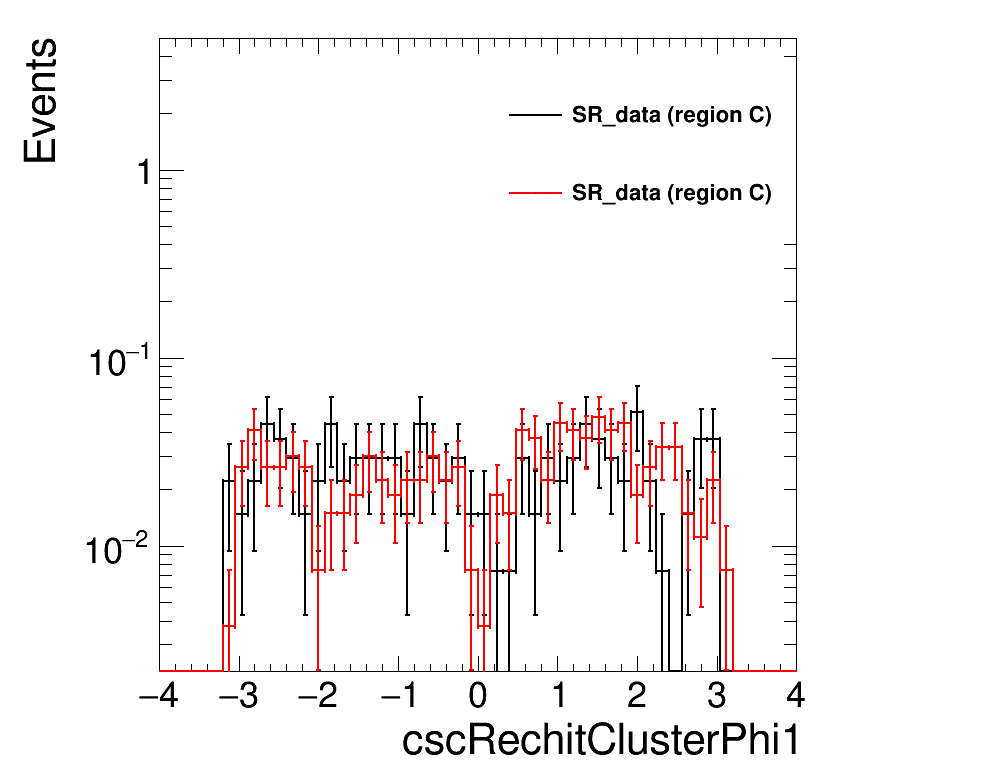

In [29]:
# Plotting ncsc
start_t = time.time()
c = rt.TCanvas('c','c', 1000, 800)
h = {}
leg = rt.TLegend(0.5,0.7,0.8,0.9)
leg.SetBorderSize(0)
plot_var = [cscRechitClusterSize1, deltaPhi_cluster, deltaR_cluster, deltaEta_cluster, met, cscRechitClusterMet_dPhi0,\
            cscRechitClusterMet_dPhi1, cscRechitClusterNStation0, cscRechitClusterNStation1,\
           cscRechitClusterAvgStation0, cscRechitClusterAvgStation1, cscRechitClusterMaxStation0, cscRechitClusterMaxStation1, rings, met, runNum,\
           cscRechitClusterEta0, cscRechitClusterEta1, cscRechitClusterPhi0, cscRechitClusterPhi1, cscRechitClusterTimeSpread0, cscRechitClusterTimeSpread1]
axis = ['N_{rechits}','#Delta#phi', "deltaR_cluster","deltaEta_cluster", "met",  'cscRechitClusterMet_dPhi0',\
            'cscRechitClusterMet_dPhi1', 'cscRechitClusterNStation0', 'cscRechitClusterN9tation1',\
       'cscRechitClusterAvgStation0', 'cscRechitClusterAvgStation1', 'cscRechitClusterMaxStation0', 'cscRechitClusterMaxStation1', "rings", "met", "runNum",\
                  'cscRechitClusterEta0', 'cscRechitClusterEta1', 'cscRechitClusterPhi0', 'cscRechitClusterPhi1', 'cscRechitClusterTimeSpread0','cscRechitClusterTimeSpread1']
name = ['nhits','dphi', "deltaR", "deltaEta_cluster","met", 'cscRechitClusterMet_dPhi0',\
            'cscRechitClusterMet_dPhi1', 'cscRechitClusterNStation0', 'cscRechitClusterNStation1',\
       'cscRechitClusterAvgStation0', 'cscRechitClusterAvgStation1', 'cscRechitClusterMaxStation0', 'cscRechitClusterMaxStation1', "rings", "met", "runNum",\
                         'cscRechitClusterEta0', 'cscRechitClusterEta1', 'cscRechitClusterPhi0', 'cscRechitClusterPhi1','cscRechitClusterTimeSpread0','cscRechitClusterTimeSpread1']
bins = [[25,50,500],[25,0,3.2], [50,0,7], [50,0,3], [50,0,200], [50,0,4], [50,-4,4], [5,0,5],[5,0,5], [50,0,5],[50,0,5], [5,0,5],[5,0,5], [20,0,20], [50,-1,500], [5000,360000,390000],\
       [50,-4,4],[50,-4,4],[50,-4,4],[50,-4,4],[50,0,50,],[50,0,50]]

plot_index = -3
i = 0
for k in plot_var[plot_index].keys():
    if not 'signal_data' in k:continue
    if "_sig_" in k:continue
    if 'invertDNN_sig' in k or 'oot_sig' in k:continue
    # if not "signal" in k:continue
    # if not "high" in k:continue
    # h = create_TH2D(np.column_stack(( np.array(cscRechitClusterSize1[k]), np.abs(deltaPhi_cluster[k]))),
                   # axis_title = ['N_{rechits}','#Delta#phi','Events'], binning=[25,50,500,25,1.8,3.2])
    # cond = np.abs(deltaPhi_cluster[k])<1.5
    # cond = cond & (cscRechitClusterSize1[k]>150) & (cscRechitClusterDNN1[k]>0.9)
    cond =  np.abs(deltaPhi_cluster[k])<2.5
    
    cond = (np.abs(np.array(cscRechitClusterEta0[k]))<1.9) & (np.abs(np.array(cscRechitClusterEta1[k]))<1.9)
    # cond = cond & (cscRechitClusterTimeSpread0[k]<20)
    # cond = cond & (cscRechitClusterTimeSpread1[k]<20)
    h[k] = create_TH1D( np.array(plot_var[plot_index][k][cond]), axis_title = [axis[plot_index],'Events'], binning=bins[plot_index],weights = np.array(weight[k][cond]))
    # check = deltaR_cluster[k]<3.5
    # print(k, np.sum(weight[k][cond&check])/np.sum(weight[k][cond]))
    # if plot_index == 0:h[k].SetMinimum(0.1)
    # else: h[k].SetMinimum(500)
    if h[k].Integral()>0: h[k].Scale(1./h[k].Integral())
    h[k].SetMaximum(5)
    if plot_index == 4:h[k].SetMinimum(1e-5)
    # h[k].SetMinimum(1e-5)
    h[k].SetLineColor(std_color_list[i])
    if "signal_data" in k:leg.AddEntry(h[k],'SR_data (region C)')
    else: leg.AddEntry(h[k],k.replace('all',''))
    h[k].Draw('hist same E1')
    i+=1
c.SetRightMargin(0.2)

# print(k, h[k].Integral(), len(cscRechitClusterSize1[k]))
# if selog: 
if plot_index == 0 or plot_index==4:c.SetLogy()
leg.Draw()
c.SetLogy()
c.Draw()

c.SaveAs(GIT_REPO + "/plots/ABCD/"+name[plot_index]+".png")
c.SaveAs(GIT_REPO + "/plots/ABCD/"+name[plot_index]+".pdf")
c.SaveAs(GIT_REPO + "/plots/ABCD/"+name[plot_index]+".C")
    



print(time.time()-start_t)

# distribution of dphi and Nrechits

invertDNN_dataall_lowMET 39.0 148
invertDNN_sig_lowMET 206.0 276
oot_dataall_lowMET 113.0 113
oot_sig_lowMET 0.0 0
signal_dataall_lowMET 99.0 99
signal_sig_lowMET 1606.0 1658
invertDNN_dataall_highMET 94.0 246
invertDNN_sig_highMET 283.0 388
oot_dataall_highMET 185.0 185
oot_sig_highMET 1.0 1
signal_dataall_highMET 200.0 200
signal_sig_highMET 2203.0 2281
867.5583035945892


Warning in <TCanvas::Constructor>: Deleting canvas with same name: c2
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Info in <TCanvas::Print>: png file /storage/af/user/christiw/login-1/christiw/LLP/Run3/CMSSW_14_0_1/src/mds_analysis/plots/ABCD/csccsc/invertDNN_dataall_lowMET.png has been created
Info in <TCanvas::Print>: pdf file /storage/af/user/christiw/login-1/christiw/LLP/Run3/CMSSW_14_0_1/src/mds_analysis/plots/ABCD/csccsc/invertDNN_dataall_lowMET.pdf has been created
Info in <TCanvas::SaveSource>: C++ Macro file: /storage/af/user/christiw/login-1/christiw/LLP/Run3/CMSSW_14_0_1/src/mds_analysis/plots/ABCD/csccsc/invertDNN_dataall_lowMET.C has been generated
Warning in <TCanvas::Constructor>: Deleting canvas with same name: c2
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Info in <TCanvas::Print>: png file /storage/af/user/christiw/login-1/christiw/LLP/Run3/CMSSW_14_0_1/src/mds_analysis/plots/ABCD/csccsc/invertDNN_si

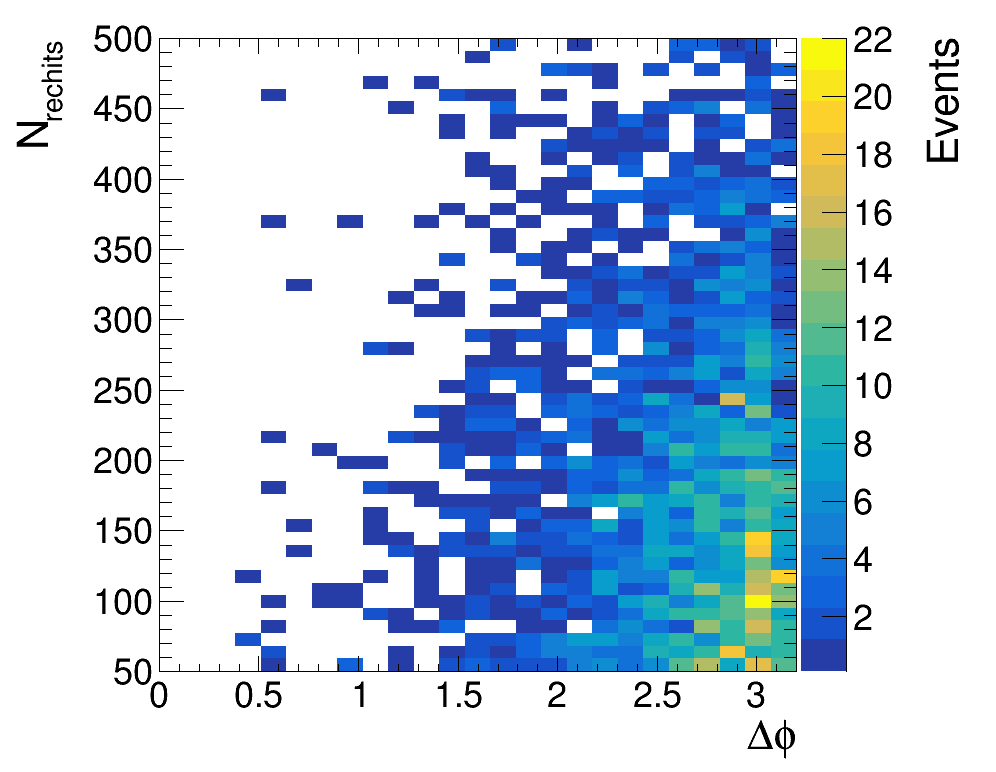

In [18]:
# Plotting ncsc


for k in cscRechitClusterSize1.keys():
    # if not "signal_dataall_lowMET" in k:continue
    c = rt.TCanvas('c2','c1', 1000, 800)
    # if not k == "invertDNN_dataall_highMET":continue
    # if not k == "oot_dataall_highMET":continue
    # if not k == "signal_sig_highMET":continue
    # cond = np.abs(deltaPhi_cluster[k])<1.5
    # cond = cond & (cscRechitClusterSize1[k]>150) & (cscRechitClusterDNN1[k]>0.9)
    # cond = cond & (deltaR_cluster[k]>0.6)
    # h = create_TH2D(np.column_stack(( np.array(cscRechitClusterSize1[k]), np.abs(deltaPhi_cluster[k]))),
                   # axis_title = ['N_{rechits}','#Delta#phi','Events'], binning=[25,50,500,25,1.8,3.2])
    # cond = (rings[k]<10) & jetVeto[k] & Flag_ecalBadCalibFilter[k]
    cond = cscRechitClusterDNN1[k]>0.9
    h = create_TH2D(np.column_stack(( np.abs(deltaPhi_cluster[k][cond]), np.array(cscRechitClusterSize1[k][cond]))),
                   axis_title = ['#Delta#phi','N_{rechits}','Events'], binning=[25,0,3.2,50,50,500,])
    # h = create_TH2D(np.column_stack(( np.abs(np.array(cscRechitClusterEta0[k][cond])), np.abs(np.array(cscRechitClusterEta1[k][cond])))),
    #                axis_title = ['eta 0','eta 1','Events'], binning=[50,0.5,3.2,50,0.5,3.2,])
    # h = create_TH2D(np.column_stack(( np.abs(np.array(cscRechitClusterSize0[k][cond])), np.abs(np.array(cscRechitClusterSize1[k][cond])))),
                   # axis_title = ['size 0','size 1','Events'], binning=[50,0,500,50,0,500,])
    # h = create_TH2D(np.column_stack(( np.array(cscRechitClusterEta0[k][cond]), np.array(cscRechitClusterPhi0[k][cond]))),
                   # axis_title = ['eta','phi','Events'], binning=[50,-3,3,50,-3.2,3.2])
    # h = create_TH2D(np.column_stack(( np.array(deltaEta_cluster[k][cond]), np.array(deltaPhi_cluster[k][cond]))),
    #                axis_title = ['eta','phi','Events'], binning=[50,-3,3,50,-3.2,3.2])
    
    # h = create_TH2D(np.column_stack(( np.array(cscRechitClusterEta1[k][cond]), np.array(cscRechitClusterPhi1[k][cond]))),
    #                axis_title = ['eta','phi','Events'], binning=[50,-3,3,50,-3.2,3.2])
    
    # print(k, np.count_nonzero(cond)/len(cond))
    h.SetMinimum(0.1)
    h.Draw('colz')
    c.SetRightMargin(0.2)

    print(k, h.Integral(), len(cscRechitClusterSize1[k]))
    # if setlog: 
    # c.SetLogz()
    c.Draw()

    c.SaveAs(GIT_REPO + "/plots/ABCD/csccsc/"+k+".png")
    c.SaveAs(GIT_REPO + "/plots/ABCD/csccsc/"+k+".pdf")
    c.SaveAs(GIT_REPO + "/plots/ABCD/csccsc/"+k+".C")




print(time.time()-start_t)

In [7]:
cscRechitClusterEta0[k]

<Array [-1.15, -1.42, 2.05, ... -1.31, 1.99] type='207 * float32'>

# ABCD (Scan Nrechits)

In [23]:
a = {}
b = {}
c = {}
d = {}
cuts = np.arange(50,106,1)
cuts = np.arange(60,300,10)
cuts = np.arange(100,250,10)
n_ev = 5000


# cuts = [90,95,100,104,105]
print(cuts)
bkg_dphiJet = []
sig_dphiJet = []
bkg_dphiCluster = []
sig_dphiCluster = []
print_jetmet = 0

table = {}
latex_table = {}

for k in cscRechitClusterSize1.keys():
    # if  not "high" in k:continue
    if "_sig_" in k:continue
    if "signal" in k:continue
    # if not "high" in k:continue
    # if not "OOT" in k:continue
    print("*****************************")
    print(f"******** {k} **********")
    print("*****************************")
    table[k] = {
    # "dPhi cuts": ['dphi', 'A', 'B', 'C', 'D', 'prediction', 'uncertainty'],
    "Nhits cuts":[],
    "A": [],
    "B": [],
    "C": [],
    "D": [],
    "pred":[],
    "uncertainty":[],
    }
    if "lowMET" in k: 

        DPHI_CUT = 2.8
        cuts = [130]
    else: 

        
        DPHI_CUT = 2.3
        cuts = [130]
        
    # if cat == "lowMET": NHIT_CUT, DPHI_CUT = 180,2.8
    # elif cat == "highMET": NHIT_CUT, DPHI_CUT = 160,2.3
    print(DPHI_CUT)
    for N_RECHIT_CUT in cuts:
        if N_RECHIT_CUT<100:continue
        cond = cscRechitClusterDNN1[k]>0.9
        var = np.abs(deltaPhi_cluster[k])
        
        a[k] = np.count_nonzero([cond & np.logical_and(cscRechitClusterSize1[k]>=N_RECHIT_CUT, var>=DPHI_CUT)])
        b[k] = np.count_nonzero([cond & np.logical_and(cscRechitClusterSize1[k]>=N_RECHIT_CUT, var<DPHI_CUT)])
        c[k] = np.count_nonzero([cond & np.logical_and(cscRechitClusterSize1[k]<N_RECHIT_CUT, var<DPHI_CUT)])
        d[k] = np.count_nonzero([cond & np.logical_and(cscRechitClusterSize1[k]<N_RECHIT_CUT, var>=DPHI_CUT)])

        # print(a[k],b[k],c[k],d[k])
        if b[k] == 0 or c[k] == 0 or d[k] ==0:break
        # if c[k] == 0:break
        pred = b[k]*d[k]/c[k]
        unc_pred = (1./c[k] + 1./b[k] + 1./d[k])**0.5*pred
        if math.isnan(unc_pred): z_value = float("nan")
        else:
            mu = np.random.normal(pred, unc_pred, n_ev)
            p_value = 0.0
            for i in mu:
                if i < 0:continue
                n = np.random.poisson(i, n_ev)
                p_value += np.count_nonzero(n>=a[k])
            p_value = p_value/n_ev**2
            z_value = abs(norm.ppf(p_value))
        print(N_RECHIT_CUT, '\t',a[k],'\t',b[k],'\t',c[k],'\t',d[k],'\t', round(pred, 2), '\t',\
              round( unc_pred, 2), '\t', round(z_value,2))
       
        table[k]['Nhits cuts'].append(N_RECHIT_CUT)
        table[k]['A'].append(a[k])
        table[k]['B'].append(b[k])
        table[k]['C'].append(c[k])
        table[k]['D'].append(d[k])
        table[k]['pred'].append(pred)
        table[k]['uncertainty'].append(unc_pred)
        
        
        
    table[k] = pd.DataFrame(table[k])
    latex_table[k] = table[k].to_latex(
    index=False,  # To not include the DataFrame index as a column in the table
    column_format="|l|l|l|l|l|",  # The format of the columns: left-aligned with vertical lines between them
    escape=False,  # Disable escaping LaTeX special characters in the DataFrame
    float_format="{:0.2f}".format  # Formats floats to two decimal places
    )

    print(latex_table[k])

[100 110 120 130 140 150 160 170 180 190 200 210 220 230 240]
*****************************
******** invertDNN_dataall_lowMET **********
*****************************
2.8
130 	 1 	 1 	 28 	 9 	 0.32 	 0.34 	 0.62
\begin{tabular}{|l|l|l|l|l|}
\toprule
 Nhits cuts &  A &  B &   C &  D &  pred &  uncertainty \\
\midrule
        130 &  1 &  1 &  28 &  9 &  0.32 &         0.34 \\
\bottomrule
\end{tabular}

*****************************
******** oot_dataall_lowMET **********
*****************************
2.8
130 	 0 	 2 	 82 	 29 	 0.71 	 0.52 	 1.34
\begin{tabular}{|l|l|l|l|l|}
\toprule
 Nhits cuts &  A &  B &   C &   D &  pred &  uncertainty \\
\midrule
        130 &  0 &  2 &  82 &  29 &  0.71 &         0.52 \\
\bottomrule
\end{tabular}

*****************************
******** invertDNN_dataall_highMET **********
*****************************
2.3
130 	 0 	 6 	 76 	 13 	 1.03 	 0.52 	 1.93
\begin{tabular}{|l|l|l|l|l|}
\toprule
 Nhits cuts &  A &  B &   C &   D &  pred &  uncertainty \\
\mid

## print table for AN

In [24]:
VR_keys = [x.replace("_dataall_", "") for x in table.keys()]
VR_keys = [x.replace("invert", "inverted ") for x in VR_keys]
VR_keys = [x.replace("lowMET", " low MET bin (MET $< $30 \GeV)") for x in VR_keys]
VR_keys = [x.replace("highMET", " high MET bin (MET $\geq$30 \GeV)") for x in VR_keys]
VR_keys = [x.replace("oot", " OOT") for x in VR_keys]


all_table = pd.concat(table.values(), keys=VR_keys)
all_table =all_table.reset_index()
all_table = all_table[["level_0", "A", "B","C","D", "pred", "uncertainty"]]
print(all_table.head())
all_table = all_table.to_latex(
    header = ["validation region", "A", "B","C","D", "prediction", "uncertainty"],
    index=False,  # To not include the DataFrame index as a column in the table
    column_format="l|l|l|l|l|l|l",  # The format of the columns: left-aligned with vertical lines between them
    escape=False,  # Disable escaping LaTeX special characters in the DataFrame
    float_format="{:0.2f}".format,  # Formats floats to two decimal places
    caption = "Validation of the background estimation method for low MET CSC-CSC category.\n \
    The uncertainty of the prediction is the statistical uncertainty propogated from bin B, C, and D.",
    label = "tab:validation_lowMET_CSCCSC",
    )
print(all_table.replace("midrule","hline"))

                                         level_0  A  B    C   D      pred  \
0     inverted DNN low MET bin (MET $< $30 \GeV)  1  1   28   9  0.321429   
1              OOT low MET bin (MET $< $30 \GeV)  0  2   82  29  0.707317   
2  inverted DNN high MET bin (MET $\geq$30 \GeV)  0  6   76  13  1.026316   
3           OOT high MET bin (MET $\geq$30 \GeV)  0  1  144  40  0.277778   

   uncertainty  
0     0.344218  
1     0.522974  
2     0.520037  
3     0.282180  
\begin{table}
\centering
\caption{Validation of the background estimation method for low MET CSC-CSC category.
     The uncertainty of the prediction is the statistical uncertainty propogated from bin B, C, and D.}
\label{tab:validation_lowMET_CSCCSC}
\begin{tabular}{l|l|l|l|l|l|l}
\toprule
                             validation region &  A &  B &    C &   D & prediction & uncertainty \\
\hline
    inverted DNN low MET bin (MET $< $30 \GeV) &  1 &  1 &   28 &   9 &       0.32 &        0.34 \\
             OOT low MET bin (

In [ ]:
                                         level_0  A  B    C    D      pred  \
0     inverted DNN low MET bin (MET $< $30 \GeV)  1  2  109   36  0.660550   
1              OOT low MET bin (MET $< $30 \GeV)  0  1  285   97  0.340351   
2  inverted DNN high MET bin (MET $\geq$30 \GeV)  3  6  153   71  2.784314   
3           OOT high MET bin (MET $\geq$30 \GeV)  3  2  286  185  1.293706   

   uncertainty  
0     0.484032  
1     0.342694  
2     1.204959  
3     0.922896  
\begin{table}
\centering
\caption{Validation of the background estimation method for low MET CSC-CSC category.
     The uncertainty of the prediction is the statistical uncertainty propogated from bin B, C, and D.}
\label{tab:validation_lowMET_CSCCSC}
\begin{tabular}{l|l|l|l|l|l|l}
\toprule
                             validation region &  A &  B &    C &    D & prediction & uncertainty \\
\hline
    inverted DNN low MET bin (MET $< $30 \GeV) &  1 &  2 &  109 &   36 &       0.66 &        0.48 \\
             OOT low MET bin (MET $< $30 \GeV) &  0 &  1 &  285 &   97 &       0.34 &        0.34 \\
 inverted DNN high MET bin (MET $\geq$30 \GeV) &  3 &  6 &  153 &   71 &       2.78 &        1.20 \\
          OOT high MET bin (MET $\geq$30 \GeV) &  3 &  2 &  286 &  185 &       1.29 &        0.92 \\
\bottomrule
\end{tabular}
\end{table}


# ABCD (Scan dPhi)

In [36]:

a = {}
b = {}
c = {}
d = {}
cuts = np.arange(50,106,1)
cuts = np.arange(0,35,2)/10
cuts = np.arange(1.0,3.2,0.05)
print(cuts)
n_ev = 5000


table = {}
latex_table = {}

for k in cscRechitClusterSize1.keys():
    # if "sig" in k:continue
    print("*****************************")
    print(f"******** {k} **********")
    print("*****************************")
    table[k] = {
        # "dPhi cuts": ['dphi', 'A', 'B', 'C', 'D', 'prediction', 'uncertainty'],
        "dPhi cuts":[],
        "A": [],
        "B": [],
        "C": [],
        "D": [],
        "pred":[],
        "uncertainty":[],
    }
    if "lowMET" in k: N_RECHIT_CUT = 160
    else:  N_RECHIT_CUT = 140
    for DPHI_CUT in cuts:
        var = np.abs(deltaPhi_cluster[k])
        
        a[k] = np.count_nonzero([np.logical_and(cscRechitClusterSize1[k]>=N_RECHIT_CUT, var>=DPHI_CUT)])
        b[k] = np.count_nonzero([np.logical_and(cscRechitClusterSize1[k]>=N_RECHIT_CUT, var<DPHI_CUT)])
        c[k] = np.count_nonzero([np.logical_and(cscRechitClusterSize1[k]<N_RECHIT_CUT, var<DPHI_CUT)])
        d[k] = np.count_nonzero([np.logical_and(cscRechitClusterSize1[k]<N_RECHIT_CUT, var>=DPHI_CUT)])

        if "lowMET" in k:
            if b[k] == 0 or c[k] == 0 or d[k] ==0:continue
            pred = b[k]*d[k]/c[k]
            unc_pred = (1./c[k] + 1./b[k] + 1./d[k])**0.5*pred
            if math.isnan(unc_pred): z_value = float("nan")
            else:
                mu = np.random.normal(pred, unc_pred, n_ev)
                p_value = 0.0
                for i in mu:
                    if i < 0:continue
                    n = np.random.poisson(i, n_ev)
                    p_value += np.count_nonzero(n>=a[k])

                p_value = p_value/n_ev**2
                z_value = abs(norm.ppf(p_value))
            print(round(DPHI_CUT,2), '\t',a[k],'\t',b[k],'\t',c[k],'\t',d[k],'\t', round(pred, 2), '\t',\
                  round( unc_pred, 2), '\t', round(z_value,2))
        else:
            if a[k] == 0 or c[k] == 0 or d[k] ==0:continue
            pred = a[k]*c[k]/d[k]
            unc_pred = (1./c[k] + 1./a[k] + 1./d[k])**0.5*pred
            if math.isnan(unc_pred): z_value = float("nan")
            else:
                mu = np.random.normal(pred, unc_pred, n_ev)
                p_value = 0.0
                for i in mu:
                    if i < 0:continue
                    n = np.random.poisson(i, n_ev)
                    p_value += np.count_nonzero(n>=b[k])
                p_value = p_value/n_ev**2
                z_value = abs(norm.ppf(p_value))
            print(round(DPHI_CUT,2), '\t',a[k],'\t',b[k],'\t',c[k],'\t',d[k],'\t', round(pred, 2), '\t',\
                  round( unc_pred, 2), '\t', round(z_value,2))
        table[k]['dPhi cuts'].append(DPHI_CUT)
        table[k]['A'].append(a[k])
        table[k]['B'].append(b[k])
        table[k]['C'].append(c[k])
        table[k]['D'].append(d[k])
        table[k]['pred'].append(pred)
        table[k]['uncertainty'].append(unc_pred)
        
        
        
    table[k] = pd.DataFrame(table[k])
    latex_table[k] = table[k].to_latex(
    index=False,  # To not include the DataFrame index as a column in the table
    column_format="|l|l|l|l|l|",  # The format of the columns: left-aligned with vertical lines between them
    escape=False,  # Disable escaping LaTeX special characters in the DataFrame
    float_format="{:0.2f}".format  # Formats floats to two decimal places
    )

    print(latex_table[k])


[1.   1.05 1.1  1.15 1.2  1.25 1.3  1.35 1.4  1.45 1.5  1.55 1.6  1.65
 1.7  1.75 1.8  1.85 1.9  1.95 2.   2.05 2.1  2.15 2.2  2.25 2.3  2.35
 2.4  2.45 2.5  2.55 2.6  2.65 2.7  2.75 2.8  2.85 2.9  2.95 3.   3.05
 3.1  3.15]
*****************************
******** lowMET_invertDNN_dataall **********
*****************************
1.95 	 20 	 1 	 97 	 742 	 7.65 	 7.69 	 1.38
2.0 	 20 	 1 	 124 	 715 	 5.77 	 5.79 	 2.0
2.05 	 19 	 2 	 154 	 685 	 8.9 	 6.34 	 1.31
2.1 	 19 	 2 	 183 	 656 	 7.17 	 5.1 	 1.83
2.15 	 19 	 2 	 216 	 623 	 5.77 	 4.1 	 2.35
2.2 	 19 	 2 	 247 	 592 	 4.79 	 3.41 	 2.8
2.25 	 19 	 2 	 282 	 557 	 3.95 	 2.81 	 3.29
2.3 	 17 	 4 	 309 	 530 	 6.86 	 3.47 	 1.99
2.35 	 15 	 6 	 340 	 499 	 8.81 	 3.65 	 1.17
2.4 	 15 	 6 	 380 	 459 	 7.25 	 3.0 	 1.65
2.45 	 15 	 6 	 398 	 441 	 6.65 	 2.75 	 1.86
2.5 	 12 	 9 	 423 	 416 	 8.85 	 3.01 	 0.66
2.55 	 11 	 10 	 462 	 377 	 8.16 	 2.64 	 0.66
2.6 	 11 	 10 	 494 	 345 	 6.98 	 2.26 	 1.01
2.65 	 11 	 10 	 531 	 3

KeyboardInterrupt: 

In [ ]:
# Optimization
deltaPhi_cluster